<a href="https://colab.research.google.com/github/PioPio31/AnaliticaDeDatos_Equipo1/blob/main/Actividad2_Valdez_Escobedo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTITUTO TECNOLOGICO DE CIUDAD JUAREZ**

**Ciencia y analítica de datos**

MODELOS DE APRENDIZAJE


**ACTIVIDAD 2**
Exploración de datos

---

*   NOMBRE:__Valdez Escobedo Montserrat__________________
*   NO. CONTROL:____23111475_______

-------

# CODIGO PARA ACCEDER A NUESTRO DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# IMPORTA LAS LIBRERIAS NECESARIAS

In [2]:
#libreria manipulacion de datos
import pandas as pd


#libreria para calculos numericos y estadisticos
import numpy as np


#libreria para graficos
import matplotlib.pyplot as plt
import seaborn as sns




# CONVIERTE ARCHIVO CSV A TIPO DataFrame (df)

In [3]:
credit_df = pd.read_csv("/content/drive/MyDrive/Analitica_Datos/credit_risk_dataset.csv")

----

# **Parte 1**. Análisis descriptivo (univariante)

1. Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas cualitativas?

<font color="orange">ESCRIBE AQUI TU RESPUESTA</FONT>
<font color="white">Numéricas: 8, cualitativas: 4</FONT>

In [4]:
#.info()muestra la informacion del dataframe numero de columnas y del tipo de dato de cada una de las columnas
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


 2. Determina el porcentaje de valores faltantes por columna.

In [5]:
#.isna() revisa si existen valores nulos
#.mean() calcula promedio
credit_df.isna().mean()*100

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


Los valores faltantes se encuentran únicamente en las variables person_emp_length, con aproximadamente 2.75 %, y loan_int_rate, con aproximadamente 9.56 %. El resto de las variables no presenta valores nulos.

----

# Análisis de variables numéricas

3. Obtén las siguientes estadísticas descriptivas para todas las variables numéricas:
*   Tendencia central (media, mediana)
*   Dispersión o variabilidad (min, max, desviación estándar, cuartiles)
*   Forma (asimetría y curtosis)
*   Clasifica las variables `person_age` y `loan_in_rate` según los valores observados de asimetría y curtosis

**NOTA**. Recuerda que muchas de estas estadísticas, puedes obtenerlas utilizando la función `describe()` y que la mediana está representada en el 2do cuartil (50%)

#

In [6]:
#AGREGUE TODAS LAS CELDAS DE CODIGO Y TEXTO QUE NECESITE

In [7]:
#Selecciona todas las variables numericas
numerical = credit_df.select_dtypes(include='number')

#Estadisticas descriptivas
numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [8]:
#Calcula la asimetria y curtosis de las variables numericas
forma = pd.DataFrame({
    'Asimetria': numerical.skew(),
    'Curtosis': numerical.kurt()
})
forma

,Asimetria,Curtosis
person_age,2.581393,18.560825
person_income,32.865349,2693.272776
person_emp_length,2.614455,43.722338
loan_amnt,1.192477,1.423565
loan_int_rate,0.208550,-0.671609
loan_status,1.364888,-0.137088
loan_percent_income,1.064669,1.223687
cb_person_cred_hist_length,1.661790,3.716194


La variable person_age presenta una asimetría positiva de 2.58, indica que los datos están sesgados hacia la derecha y que la distribución **no es simétrica**. Además, presenta una curtosis de 18.56, por lo que se clasifica como **leptocúrtica**.

En cambio, la variante loan_int_rate presenta una **asimetría** de 0.21. Al ser un valor cercano a cero, su distribución es aproximadamente simétrica. Su curtosis es de -0.67, por lo que se clasifica como **platicúrtica**

------

4. Utiliza histogramas para determinar la distribución de los valores representados en cada variable.
*   ¿Se corresponde con lo obtenido en el cálculo de asimetría? Como verás, los datos reales son más complejos que la teoría. Por esta razón, recuerda siempre acompañar el análisis de la asimetría con algún gráfico como un histograma.

**NOTA**. Para esto también puedes ocupar los gráficos `kde` ([kernel density estimation](https://www.cienciadedatos.net/documentos/pystats02-kernel-density-estimation-kde-python.html)) que crean una curva continua y suave expandiendo la idea del histograma.

<font color="orange">AGREGA LA RESPUESTA A LA PREGUNTA AQUI</FONT>

In [9]:
#AGREGA TODAS LAS CELDAS DE CODIGO Y TEXTO QUE NECESITES

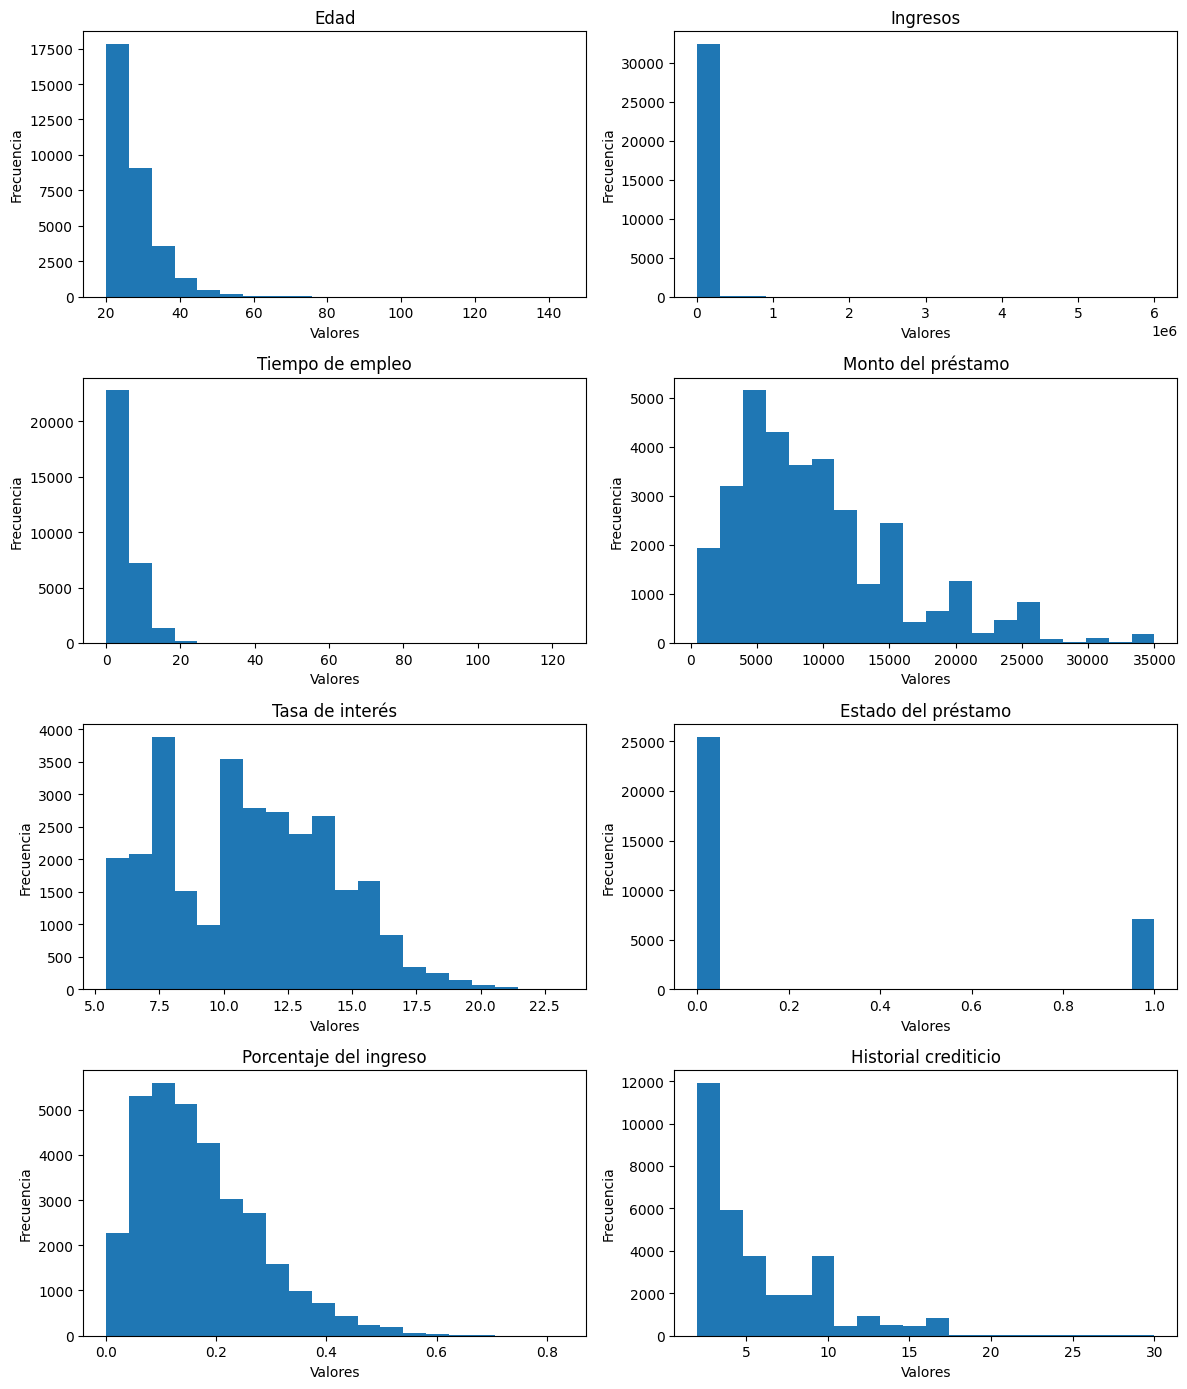

In [10]:
#Creacion de las variables numericas
titulos = [
    "Edad",
    "Ingresos",
    "Tiempo de empleo",
    "Monto del préstamo",
    "Tasa de interés",
    "Estado del préstamo",
    "Porcentaje del ingreso",
    "Historial crediticio"
]

fig, axes = plt.subplots(4, 2, figsize = (12, 14))
axes = axes.flatten()

for i, columna in enumerate (numerical.columns):
  axes[i].hist(credit_df[columna].dropna(), bins = 20)
  axes[i].set_title(titulos[i])
  axes[i].set_xlabel("Valores")
  axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

En general, los histogramas muestran que la mayoría de las variables se concentra en valores bajos y presenta una extensión hacia valores mayores, lo que coincide con la asimetría positiva calculada anteriormente. Esto se observa especialmente en variables como person_income, person_age, loan_amnt y loan_percent_income.
Por otro lado, loan_int_rate presenta una distribución más equilibrada, lo cual corresponde con su valor de asimetría cercano a cero. En conjunto, las gráficas permiten identificar de forma visual cómo se distribuyen las características de las personas y de los préstamos dentro del conjunto de datos.

----

5. Emplea boxplots para mostrar la distribución de los datos a través de sus cuartiles.

In [11]:
#AGREGA TODAS LAS CELDAS DE CODIGO Y TEXTO QUE NECESITES

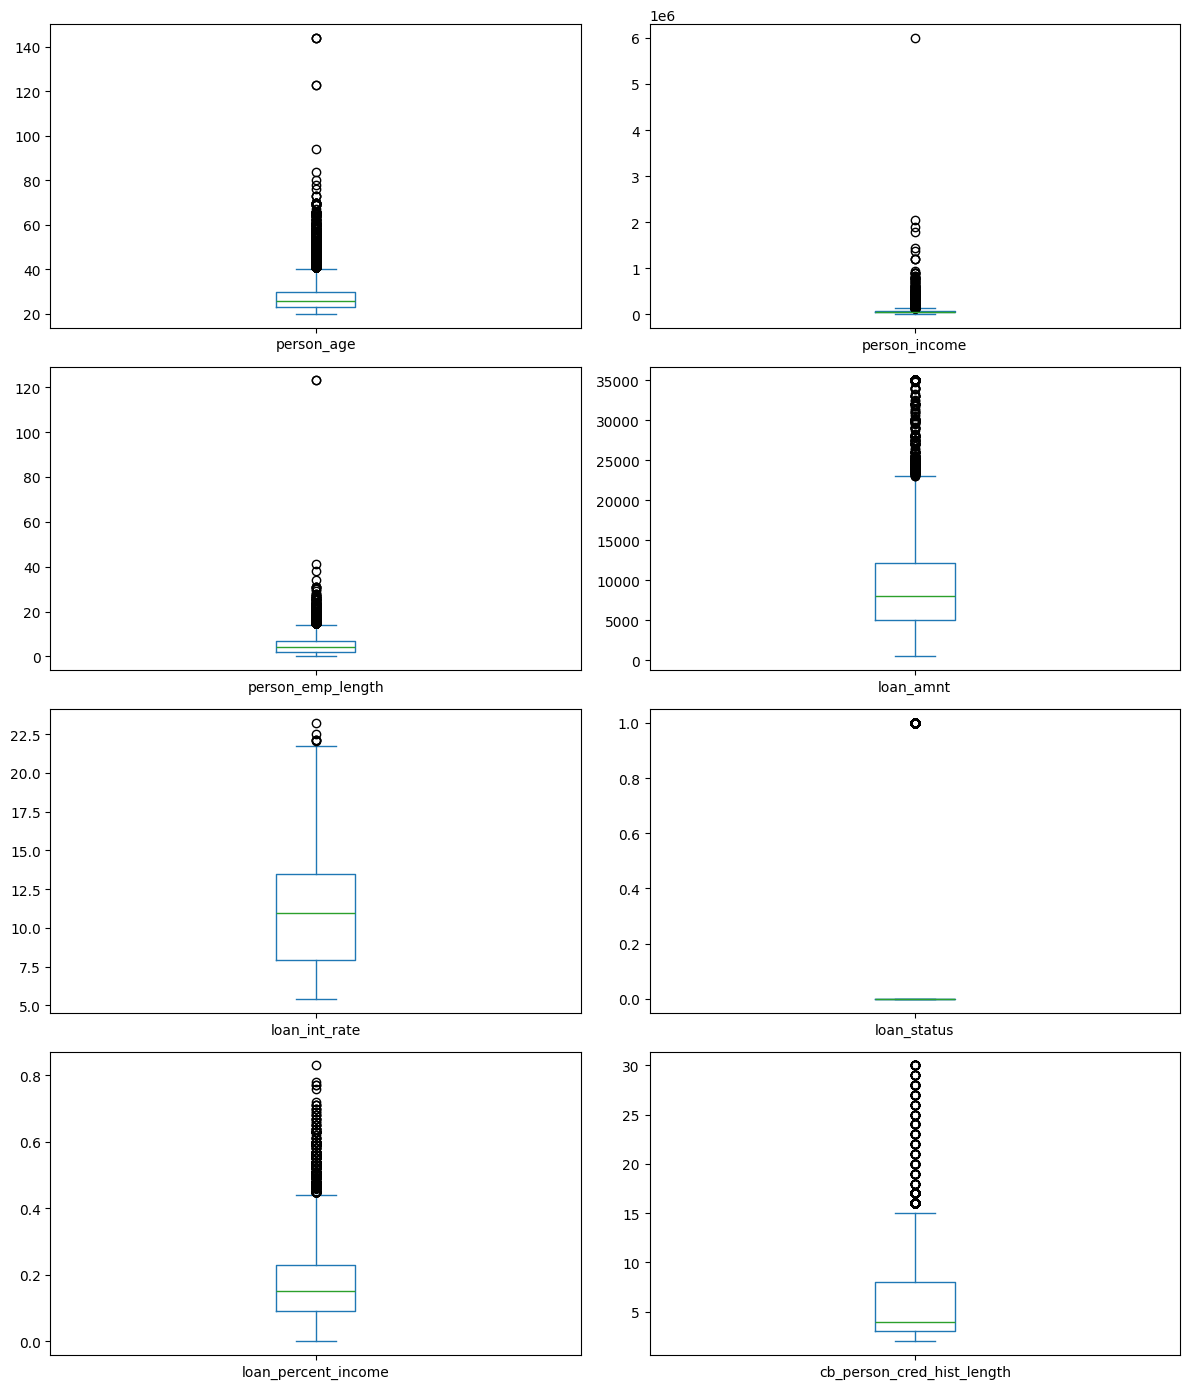

In [22]:
#Diagramas de caja de las variables numericas
numerical.plot(
    kind='box',
    subplots=True,
    layout=(4,2),
    figsize=(12,14),
    sharex=False,
    sharey=False
)
plt.tight_layout()
plt.show()

-----

*   Como podrás observar hay valores atípicos en todas las variables. Ejecuta el siguiente código para identificar los valores atípicos en la variable `person_age`

**Interpretación Resultados**

<FONT COLOR="ORANGE">AGREGA AQUI LA INTERPRETACION DE TUS RESULTADOS</FONT>

In [23]:
#COMENTE CADA LINEA DE CODIGO EXPLICANDO SU USO
# Calcula el primer cuartil (Q1), correspondiente al 25% de los datos
percentile_25 = credit_df["person_age"].quantile(0.25)

# Calcula el tercer cuartil (Q3), correspondiente al 75% de los datos
percentile_75 = credit_df["person_age"].quantile(0.75)

# Calcula el rango intercuartílico restando Q1 a Q3
iqr = percentile_75 - percentile_25

# Calcula los límites superior e inferior para identificar valores atípicos
upper_limit = percentile_75 + 1.5 * iqr
lower_limit = percentile_25 - 1.5 * iqr

# Selecciona los registros que se encuentran fuera de los límites establecidos
IQR_outliers = credit_df[(credit_df["person_age"] < lower_limit) | (credit_df["person_age"] > upper_limit)]

# Muestra los valores atípicos encontrados
IQR_outliers

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
29121,50,900000,MORTGAGE,11.0,DEBTCONSOLIDATION,B,30000,12.69,0,0.03,N,15
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


Mediante el método IQR se obtuvo un rango intercuartílico de 7 años, con un límite inferior de 12.5 y un límite superior de 40.5. Se identificaron 1,494 registros como valores atípicos, correspondientes principalmente a personas mayores de 40.5 años. Esto indica que la mayor parte de las edades se concentra entre valores relativamente bajos y que existe una menor cantidad de personas con edades mayores.

-----

# Análisis de variables de texto

 6. Obtén las siguientes estadísticas descriptivas para todas las variables de texto:
*   Tendencia central (moda)
*   Cardinalidad (cantidad de valores únicos)
*   Recuentos únicos (número de ocurrencias para cada valor único)

**NOTA**. Un resumen de estas estadísticas, puedes obtenerlas indicando en la función `describe()` que se incluirán sólo las variables de tipo object: `describe(include = 'object')`. Para los recuentos utiliza la función `df['columna'].value_counts()`

In [13]:
#IDENTIFIQUE CUALES SON LAS VARIABLES DE TEXTO
credit_df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [14]:
#AGREGUE TODAS LAS CELDAS DE TEXTO Y CODIGO QUE NECESITE
credit_df['person_home_ownership'].describe()

,person_home_ownership
count,32581
unique,4
top,RENT
freq,16446


In [15]:
credit_df['person_home_ownership'].value_counts()

,count
person_home_ownership,
RENT,16446
MORTGAGE,13444
OWN,2584
OTHER,107


In [16]:
credit_df['loan_intent'].describe()

,loan_intent
count,32581
unique,6
top,EDUCATION
freq,6453


In [17]:
credit_df['loan_intent'].value_counts()

,count
loan_intent,
EDUCATION,6453
MEDICAL,6071
VENTURE,5719
PERSONAL,5521
DEBTCONSOLIDATION,5212
HOMEIMPROVEMENT,3605


In [18]:
credit_df['loan_grade'].describe()

,loan_grade
count,32581
unique,7
top,A
freq,10777


In [24]:
credit_df['loan_grade'].value_counts()

,count
loan_grade,
A,10777
B,10451
C,6458
D,3626
E,964
F,241
G,64


In [25]:
credit_df['cb_person_default_on_file'].describe()

,cb_person_default_on_file
count,32581
unique,2
top,N
freq,26836


In [26]:
credit_df['cb_person_default_on_file'].value_counts()

,count
cb_person_default_on_file,
N,26836
Y,5745


-----

7. Utiliza gráficos de barras por variable para representar la frecuencia de cada categoría.

**NOTA**. seaborn posee un gráfico de recuento, para variables de tipo object, que calcula la frecuencia de cada categoría sin necesidad de utilizar la función `value_counts()`. Para generarlo debes indicar la columna: `sns.countplot(x='columna', data=df) `

In [19]:
#AGREGUE TODAS LAS CELDAS DE CODIGO Y TEXTO QUE NECESITE

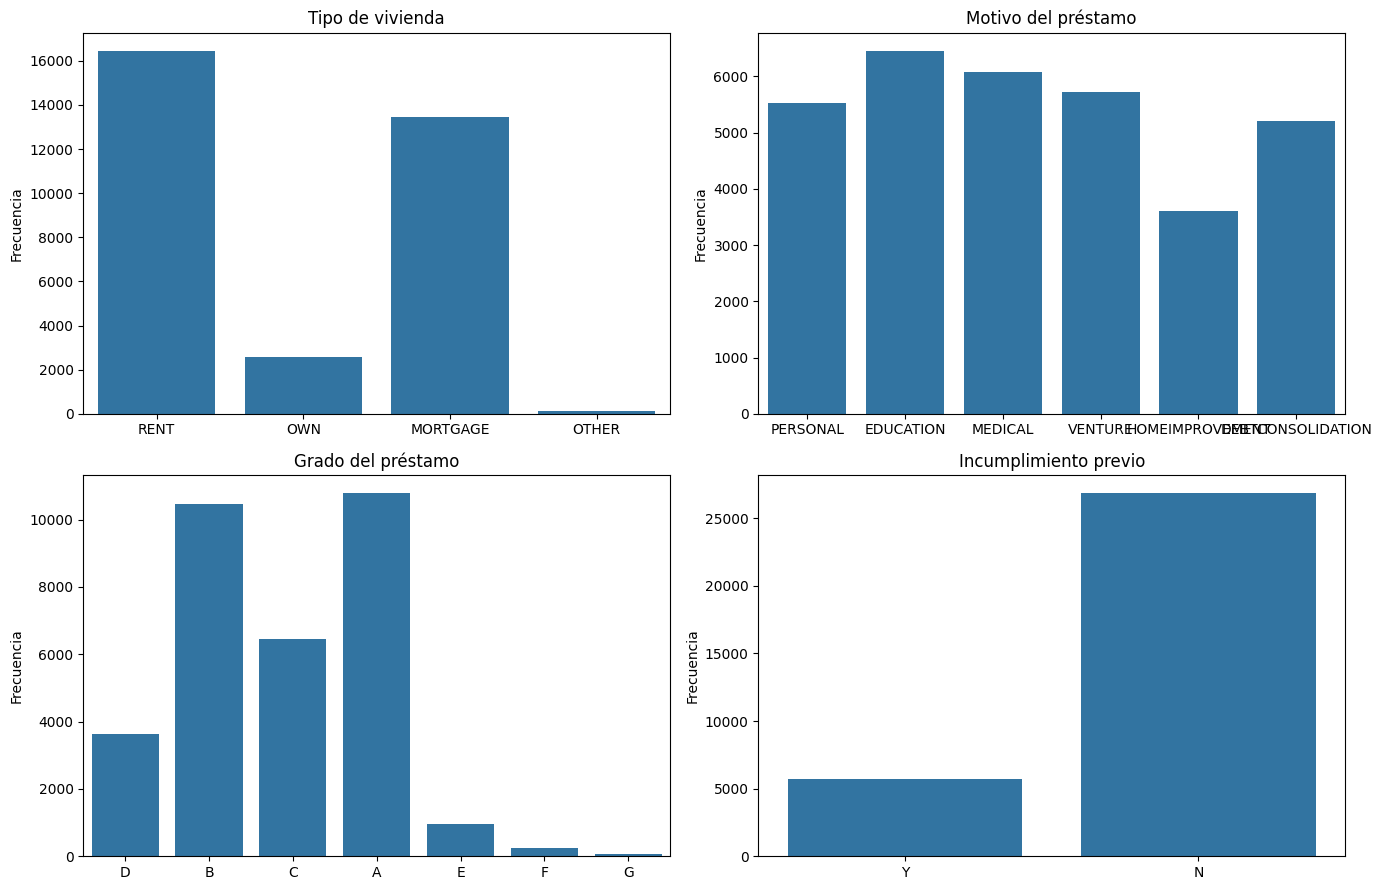

In [35]:
texto = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

titulos = ['Tipo de vivienda', 'Motivo del préstamo', 'Grado del préstamo', 'Incumplimiento previo']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, columna in enumerate(texto):
    sns.countplot(data=credit_df, x=columna, ax=axes[i])
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Los gráficos muestran que la mayoría de las personas rentan su vivienda, mientras que el motivo de préstamo más frecuente es educación. En cuanto al grado del préstamo, predomina la categoría A y, para el historial de incumplimiento, la mayoría de los registros corresponde a N, indicando que predominan las personas sin incumplimientos previos registrados.

-----

# **Parte 2**. Análisis de correlación (bivariante y multivariante)

La variable `loan_status` será la variable de salida (o a predecir en un modelo de ML). Analiza su relación con el resto de las variables a través de los siguientes gráficos:

8. Un box plot para visualizar la distribución de `loan_percent_income` según el `loan_status`. Interpreta el resultado.

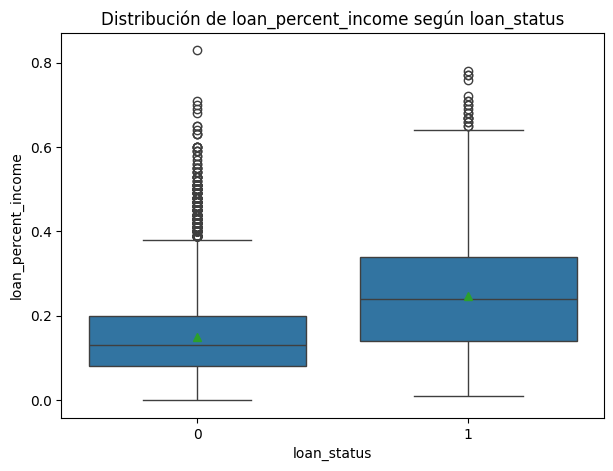

In [33]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=credit_df,
    x="loan_status",
    y="loan_percent_income",
    showmeans=True
)

plt.title("Distribución de loan_percent_income según loan_status")
plt.xlabel("loan_status")
plt.ylabel("loan_percent_income")

plt.show()

El diagrama de caja permite comparar la distribución de loan_percent_income para cada valor de loan_status. A través de la mediana, los cuartiles y los valores atípicos, se puede observar si el porcentaje del ingreso destinado al préstamo presenta diferencias entre ambos grupos. Esto permite identificar si esta variable puede tener alguna relación con el estado del préstamo.

**Interpretación resultados**

<FONT COLOR="ORANGE">AGREGUE AQUI SU RESPUESTA</FONT>



 9. En los gráficos de barras que obtuviste en el ejercicio 7, separa el conteo según el `load_status`, utilizando el parámetro `hue`.

In [20]:
#AGREGUE TODAS LAS CELDAS DE CODIGO Y TEXTO QUE NECESITE

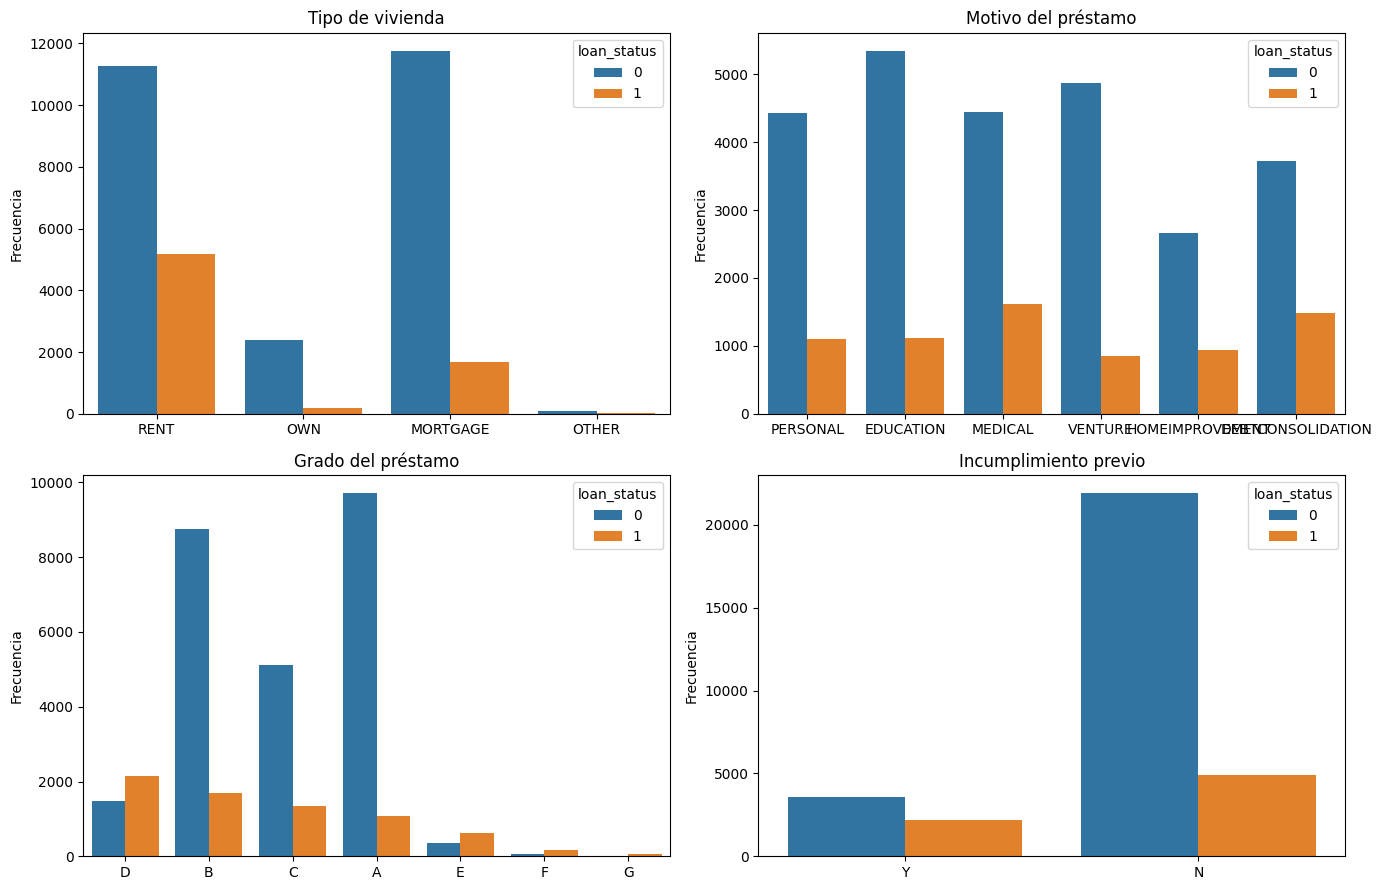

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, columna in enumerate(texto):
    sns.countplot(data=credit_df, x=columna, hue='loan_status', ax=axes[i])
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Los gráficos permiten comparar la frecuencia de cada categoría según el valor de loan_status. De esta manera se pueden observar diferencias en el comportamiento del estado del préstamo dependiendo del tipo de vivienda, el motivo del préstamo, el grado asignado y el historial de incumplimiento previo.

10. Un mapa de calor con los valores de correlación de todas las variables del dataframe.
*   ¿Qué variable tiene mayor correlación con `loan_status`?

**Respuesta a pregunta**

<FONT COLOR="ORANGE">AGREGUE SU RESPUESTA AQUI</FONT>



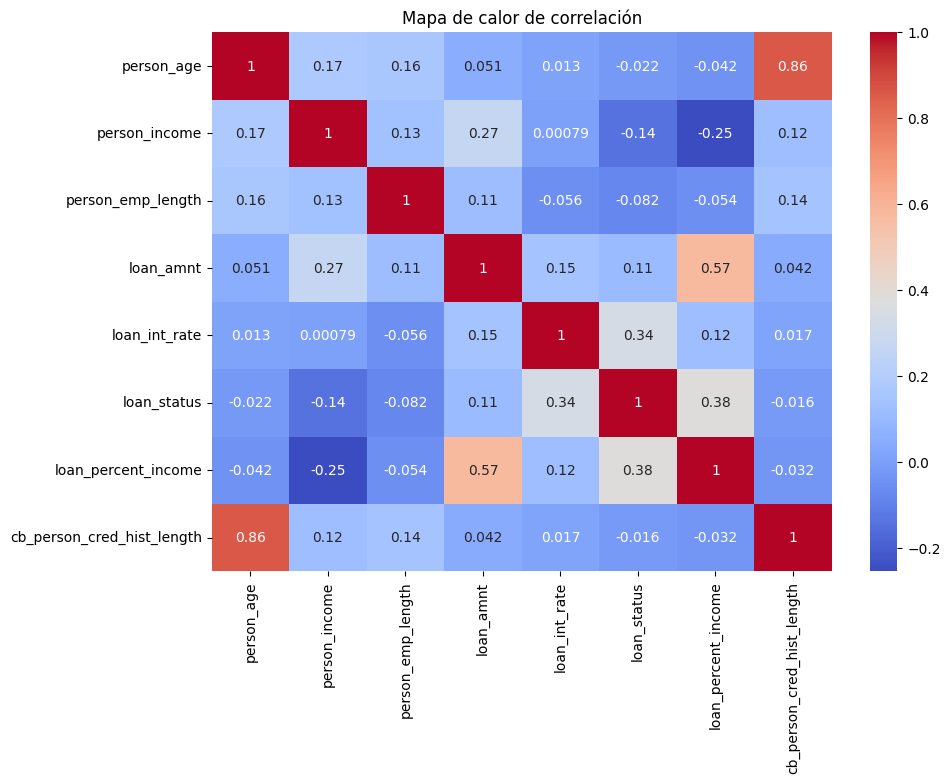

In [40]:
#CODIGO PARA MAPA DE CALOR
correlacion = credit_df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))

sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlación')
plt.show()

La variable que presenta mayor correlación con loan_status es loan_percent_income, con un coeficiente de 0.38. Esto indica una relación positiva entre el porcentaje del ingreso destinado al préstamo y el estado del préstamo. También se observa una relación positiva con loan_int_rate, con una correlación de 0.34.